# Fake News Detection using LSTM

Member 02

Deep Learning Model: Long Short-Term Memory Network

Dataset: Fake and Real News Dataset

## Objective

The objective of this notebook is to develop and evaluate an LSTM deep learning model for classifying news articles as Fake News or Real News.

In [2]:
import os
import re
import json
import pickle
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("All required libraries imported successfully.")

TensorFlow version: 2.21.0
All required libraries imported successfully.


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds configured successfully.")

Random seeds configured successfully.


In [4]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK resources downloaded successfully.")

NLTK resources downloaded successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 1. Data Collection and Loading

The Fake.csv and True.csv datasets are loaded separately.

- Fake News = 0
- Real News = 1

In [5]:
fake_path = "../data/Fake.csv"
true_path = "../data/True.csv"

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print("Fake dataset shape:", fake_df.shape)
print("True dataset shape:", true_df.shape)

display(fake_df.head())
display(true_df.head())

Fake dataset shape: (23481, 4)
True dataset shape: (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
fake_df["label"] = 0
true_df["label"] = 1

df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)
print("\nDataset columns:", df.columns.tolist())

Combined dataset shape: (44898, 5)

Dataset columns: ['title', 'text', 'subject', 'date', 'label']


## 2. Initial Dataset Inspection

The dataset is inspected to identify missing values, duplicate records, data types, and the distribution of Fake and Real news articles.

In [7]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nClass Distribution:")
class_counts = (
    df["label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Fake News", 1: "Real News"})
)

print(class_counts)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB

Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate Rows:
209

Class Distribution:
label
Fake News    23481
Real News    21417
Name: count, dtype: int64


## 3. Handling Duplicate Records

Duplicate news articles are removed to prevent data leakage and improve the reliability of model evaluation.

In [8]:
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
duplicates_removed = rows_before - rows_after

print("Rows before removing duplicates:", rows_before)
print("Duplicate rows removed:", duplicates_removed)
print("Rows after removing duplicates:", rows_after)

Rows before removing duplicates: 44898
Duplicate rows removed: 209
Rows after removing duplicates: 44689


## 4. Preparing News Content

The title and article text are combined into one content column so that the LSTM model can learn from both the headline and the complete article.

In [9]:
df["title"] = df["title"].fillna("").astype(str)
df["text"] = df["text"].fillna("").astype(str)

df["content"] = (
    df["title"].str.strip()
    + " "
    + df["text"].str.strip()
).str.strip()

print("Content column created successfully.")
display(df[["title", "text", "content", "label"]].head())

Content column created successfully.


,title,text,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Donald Trump Sends Out Embarrassing New Year’s...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Drunk Bragging Trump Staffer Started Russian C...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Sheriff David Clarke Becomes An Internet Joke ...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Trump Is So Obsessed He Even Has Obama’s Name ...,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Pope Francis Just Called Out Donald Trump Duri...,0


## 5. Text Preprocessing

The following preprocessing steps are applied:

1. Lowercasing
2. URL removal
3. HTML tag removal
4. Special-character and number removal
5. Tokenization
6. Stop-word removal
7. Lemmatization
8. Extra-space removal

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    """Clean and preprocess a news article."""

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove punctuation, numbers and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenization
    tokens = text.split()

    # Stop-word removal and lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    cleaned_text = " ".join(cleaned_tokens)

    return re.sub(r"\s+", " ", cleaned_text).strip()


print("Text preprocessing function created successfully.")

Text preprocessing function created successfully.


In [11]:
sample_text = """
BREAKING NEWS!!! Scientists published a report at
https://example.com in 2026 about several discoveries.
"""

print("Original text:")
print(sample_text)

print("\nCleaned text:")
print(clean_text(sample_text))

Original text:

BREAKING NEWS!!! Scientists published a report at
https://example.com in 2026 about several discoveries.


Cleaned text:
breaking news scientist published report several discovery


In [12]:
print("Text preprocessing started...")

df["cleaned_content"] = df["content"].apply(clean_text)

print("Text preprocessing completed successfully.")

display(
    df[
        ["content", "cleaned_content", "label"]
    ].head()
)

Text preprocessing started...
Text preprocessing completed successfully.


,content,cleaned_content,label
0,Donald Trump Sends Out Embarrassing New Year’s...,donald trump sends embarrassing new year eve m...,0
1,Drunk Bragging Trump Staffer Started Russian C...,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke ...,sheriff david clarke becomes internet joke thr...,0
3,Trump Is So Obsessed He Even Has Obama’s Name ...,trump obsessed even obama name coded website i...,0
4,Pope Francis Just Called Out Donald Trump Duri...,pope francis called donald trump christmas spe...,0


In [13]:
empty_records = (
    df["cleaned_content"].str.strip() == ""
).sum()

print("Empty records after preprocessing:", empty_records)

Empty records after preprocessing: 9


In [14]:
rows_before_empty_removal = len(df)

df = df[
    df["cleaned_content"].str.strip() != ""
].reset_index(drop=True)

rows_after_empty_removal = len(df)

print(
    "Empty records removed:",
    rows_before_empty_removal - rows_after_empty_removal
)

print(
    "Final dataset shape:",
    df.shape
)

Empty records removed: 9
Final dataset shape: (44680, 7)


## 6. Dataset Shuffling

The dataset is shuffled to mix Fake and Real news articles. A fixed random state is used for reproducible results.

In [15]:
df = df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Dataset shuffled successfully.")

display(
    df[
        ["cleaned_content", "label"]
    ].head()
)

Dataset shuffled successfully.


,cleaned_content,label
0,lie witness news jimmy kimmel show asks people...,0
1,korea latest missile launch aimed testing carr...,0
2,israeli pm netanyahu quoted full throated supp...,0
3,dems tell kanye west shut sing banned giving a...,0
4,guardian photographer year zohra bensemra reut...,1


In [16]:
X = df["cleaned_content"]
y = df["label"]

print("Number of news articles:", len(X))
print("Number of labels:", len(y))

print("\nClass distribution:")
print(y.value_counts().sort_index())

Number of news articles: 44680
Number of labels: 44680

Class distribution:
label
0    23469
1    21211
Name: count, dtype: int64


## 7. Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

Stratified sampling preserves the Fake and Real class distribution.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training records: 35744
Testing records: 8936

Training class distribution:
label
0    18775
1    16969
Name: count, dtype: int64

Testing class distribution:
label
0    4694
1    4242
Name: count, dtype: int64


## 8. Tokenization and Sequence Preparation

A Keras Tokenizer is fitted only on the training data to avoid data leakage. Each word is converted into an integer index.

In [18]:
VOCAB_SIZE = 30000
MAX_LENGTH = 300
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("Tokenizer fitted successfully.")
print("Total words found:", len(tokenizer.word_index))
print("Configured vocabulary size:", VOCAB_SIZE)

print("\nExample sequence:")
print(X_train_sequences[0][:30])

Tokenizer fitted successfully.
Total words found: 93848
Configured vocabulary size: 30000

Example sequence:
[2012, 6753, 350, 315, 36, 4, 1855, 75, 1590, 636, 2012, 1176, 9, 124, 47, 3957, 409, 9, 124, 57, 2475, 8713, 920, 527, 401, 2012, 55, 3661, 613, 398]


In [19]:
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

print("Training padded shape:", X_train_padded.shape)
print("Testing padded shape:", X_test_padded.shape)

print("Training labels shape:", y_train_array.shape)
print("Testing labels shape:", y_test_array.shape)

Training padded shape: (35744, 300)
Testing padded shape: (8936, 300)
Training labels shape: (35744,)
Testing labels shape: (8936,)


## 9. LSTM Model Architecture

The model contains:

- An Embedding layer to convert word indexes into dense vectors
- A Bidirectional LSTM layer to learn context from both directions
- Dropout layers to reduce overfitting
- Dense layers for binary classification
- A sigmoid output layer to classify Fake or Real news

In [20]:
EMBEDDING_DIM = 128
LSTM_UNITS = 64

actual_vocab_size = min(
    VOCAB_SIZE,
    len(tokenizer.word_index) + 1
)

lstm_model = Sequential([
    tf.keras.Input(shape=(MAX_LENGTH,)),

    Embedding(
        input_dim=actual_vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(
        LSTM(
            LSTM_UNITS,
            return_sequences=False
        )
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

print("LSTM model created successfully.")

LSTM model created successfully.


## 10. Model Compilation

Binary cross-entropy is used as the loss function because the task contains two classes:

- Fake News
- Real News

In [21]:
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("LSTM model compiled successfully.")

LSTM model compiled successfully.


In [22]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,137 (15.06 MB)

 Trainable params: 3,947,137 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

models_directory = project_root / "models"
models_directory.mkdir(exist_ok=True)

checkpoint_path = models_directory / "best_lstm_model.keras"

print("Checkpoint path:")
print(checkpoint_path)

Checkpoint path:
c:\Users\User\Documents\NLP_Group_39\models\best_lstm_model.keras


In [24]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_learning_rate = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=0.000001,
    verbose=1
)

callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_learning_rate
]

print("Training callbacks created successfully.")

Training callbacks created successfully.


## 11. LSTM Model Training

The LSTM model is trained using the training dataset. A validation split and callbacks are used to monitor performance and reduce overfitting.

In [25]:
EPOCHS = 8
BATCH_SIZE = 128

print("LSTM model training started...")

history = lstm_model.fit(
    X_train_padded,
    y_train_array,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    callbacks=callbacks,
    verbose=1
)

print("LSTM model training completed.")

LSTM model training started...
Epoch 1/8
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.9750 - loss: 0.0735
Epoch 1: val_loss improved from None to 0.00726, saving model to c:\Users\User\Documents\NLP_Group_39\models\best_lstm_model.keras

Epoch 1: finished saving model to c:\Users\User\Documents\NLP_Group_39\models\best_lstm_model.keras
224/224 ━━━━━━━━━━━━━━━━━━━━ 185s 810ms/step - accuracy: 0.9750 - loss: 0.0735 - val_accuracy: 0.9987 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 2/8
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.9997 - loss: 0.0022
Epoch 2: val_loss improved from 0.00726 to 0.00553, saving model to c:\Users\User\Documents\NLP_Group_39\models\best_lstm_model.keras

Epoch 2: finished saving model to c:\Users\User\Documents\NLP_Group_39\models\best_lstm_model.keras
224/224 ━━━━━━━━━━━━━━━━━━━━ 181s 808ms/step - accuracy: 0.9997 - loss: 0.0022 - val_accuracy: 0.9985 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 3/8
224/224 ━━━━━━━━━━━━━━━━━━━━

In [26]:
training_history = pd.DataFrame(history.history)

display(training_history)

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.974996,0.073514,0.998741,0.007256,0.0010
1,0.999650,0.002217,0.998461,0.005528,0.0010
2,0.999895,0.000612,0.998741,0.008036,0.0010
3,0.999825,0.001221,0.998601,0.005821,0.0005


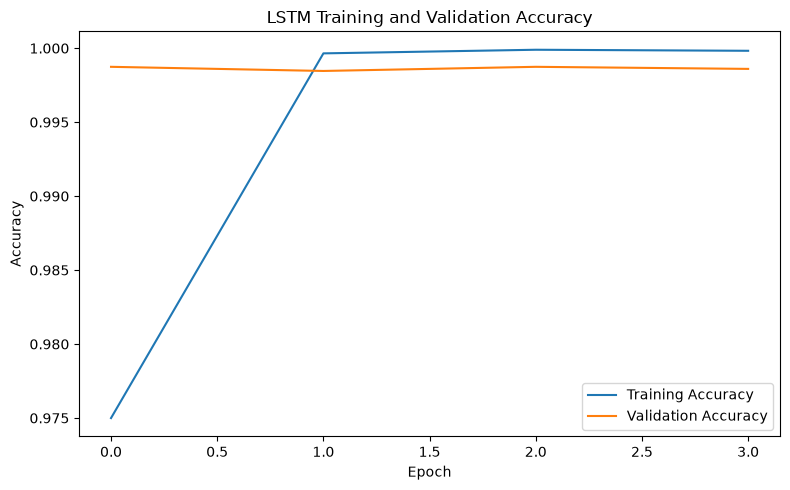

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

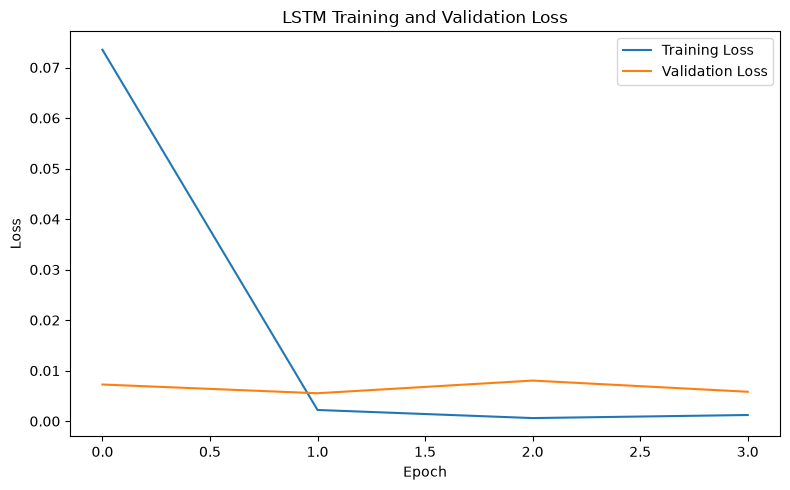

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Loading the Best LSTM Model

The best-performing model saved during training is loaded for final testing and evaluation.

In [29]:
best_lstm_model = tf.keras.models.load_model(
    checkpoint_path
)

print("Best LSTM model loaded successfully.")

Best LSTM model loaded successfully.


In [30]:
test_loss, test_accuracy = best_lstm_model.evaluate(
    X_test_padded,
    y_test_array,
    batch_size=128,
    verbose=1
)

print("\nLSTM Test Results")
print("-------------------------")
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.9989 - loss: 0.0064

LSTM Test Results
-------------------------
Test Loss    : 0.0064
Test Accuracy: 0.9989


In [31]:
y_probability = best_lstm_model.predict(
    X_test_padded,
    batch_size=128,
    verbose=1
).ravel()

y_pred = (y_probability >= 0.5).astype(int)

print("Test predictions generated successfully.")
print("Number of predictions:", len(y_pred))

70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step
Test predictions generated successfully.
Number of predictions: 8936


In [32]:
accuracy = accuracy_score(
    y_test_array,
    y_pred
)

precision = precision_score(
    y_test_array,
    y_pred
)

recall = recall_score(
    y_test_array,
    y_pred
)

f1 = f1_score(
    y_test_array,
    y_pred
)

roc_auc = roc_auc_score(
    y_test_array,
    y_probability
)

print("LSTM Evaluation Results")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

LSTM Evaluation Results
--------------------------------
Accuracy : 0.9989
Precision: 0.9991
Recall   : 0.9986
F1-Score : 0.9988
ROC-AUC  : 0.9998


In [33]:
print("Classification Report:")

print(
    classification_report(
        y_test_array,
        y_pred,
        target_names=[
            "Fake News",
            "Real News"
        ],
        digits=4
    )
)


Classification Report:
              precision    recall  f1-score   support

   Fake News     0.9987    0.9991    0.9989      4694
   Real News     0.9991    0.9986    0.9988      4242

    accuracy                         0.9989      8936
   macro avg     0.9989    0.9989    0.9989      8936
weighted avg     0.9989    0.9989    0.9989      8936



Confusion Matrix:
[[4690    4]
 [   6 4236]]


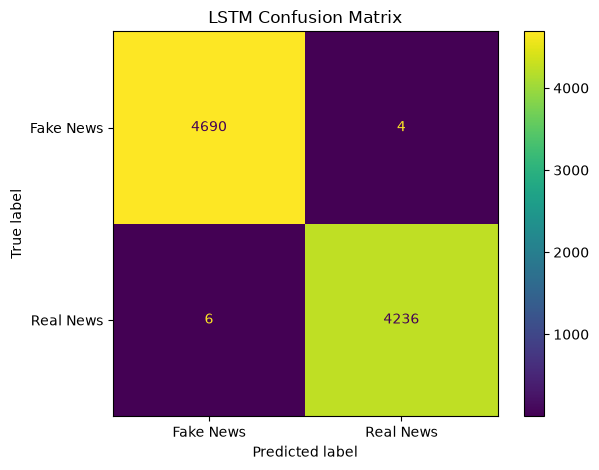

In [34]:
confusion = confusion_matrix(
    y_test_array,
    y_pred
)

print("Confusion Matrix:")
print(confusion)

matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "Fake News",
        "Real News"
    ]
)

matrix_display.plot(
    values_format="d"
)

plt.title("LSTM Confusion Matrix")
plt.tight_layout()
plt.show()

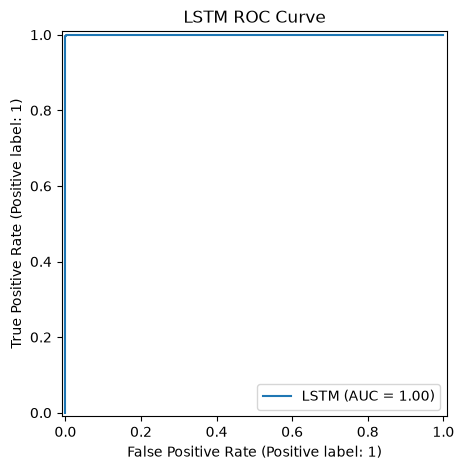

In [35]:
RocCurveDisplay.from_predictions(
    y_test_array,
    y_probability,
    name="LSTM"
)

plt.title("LSTM ROC Curve")
plt.tight_layout()
plt.show()

## 13. Saving the LSTM Model Components

The best LSTM model, tokenizer, configuration settings, evaluation metrics, and test predictions are saved for future use with unseen news articles.

In [36]:
tokenizer_path = models_directory / "lstm_tokenizer.pkl"

with open(tokenizer_path, "wb") as file:
    pickle.dump(tokenizer, file)

print("LSTM tokenizer saved successfully:")
print(tokenizer_path)

LSTM tokenizer saved successfully:
c:\Users\User\Documents\NLP_Group_39\models\lstm_tokenizer.pkl


In [37]:
lstm_config = {
    "vocab_size": int(actual_vocab_size),
    "configured_vocab_size": int(VOCAB_SIZE),
    "max_length": int(MAX_LENGTH),
    "embedding_dim": int(EMBEDDING_DIM),
    "lstm_units": int(LSTM_UNITS),
    "prediction_threshold": 0.5,
    "label_mapping": {
        "0": "Fake News",
        "1": "Real News"
    }
}

config_path = models_directory / "lstm_config.json"

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(lstm_config, file, indent=4)

print("LSTM configuration saved successfully:")
print(config_path)

LSTM configuration saved successfully:
c:\Users\User\Documents\NLP_Group_39\models\lstm_config.json


In [38]:
reports_directory = project_root / "reports"
reports_directory.mkdir(exist_ok=True)

lstm_metrics = {
    "model": "Bidirectional LSTM",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc),
    "training_records": int(len(X_train_padded)),
    "testing_records": int(len(X_test_padded)),
    "max_sequence_length": int(MAX_LENGTH),
    "vocabulary_size": int(actual_vocab_size)
}

metrics_path = reports_directory / "lstm_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(lstm_metrics, file, indent=4)

print("LSTM metrics saved successfully:")
print(metrics_path)

LSTM metrics saved successfully:
c:\Users\User\Documents\NLP_Group_39\reports\lstm_metrics.json


In [39]:
lstm_prediction_results = pd.DataFrame({
    "Cleaned_Text": X_test.reset_index(drop=True),
    "Actual_Label": y_test.reset_index(drop=True),
    "Predicted_Label": y_pred,
    "Real_Probability": y_probability
})

lstm_prediction_results["Fake_Probability"] = (
    1 - lstm_prediction_results["Real_Probability"]
)

lstm_prediction_results["Actual_Class"] = (
    lstm_prediction_results["Actual_Label"]
    .map({
        0: "Fake News",
        1: "Real News"
    })
)

lstm_prediction_results["Predicted_Class"] = (
    lstm_prediction_results["Predicted_Label"]
    .map({
        0: "Fake News",
        1: "Real News"
    })
)

prediction_path = (
    reports_directory / "lstm_test_predictions.csv"
)

lstm_prediction_results.to_csv(
    prediction_path,
    index=False
)

print("LSTM test predictions saved successfully:")
print(prediction_path)

LSTM test predictions saved successfully:
c:\Users\User\Documents\NLP_Group_39\reports\lstm_test_predictions.csv
